<a href="https://colab.research.google.com/github/SulemanQB/FedMeta_MNIST/blob/main/FedMeta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize the data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape the data
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# Split the training data into multiple clients for federated learning
num_clients = 10
client_data = np.array_split(x_train, num_clients)
client_labels = np.array_split(y_train, num_clients)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
def create_model():
    model = keras.Sequential([
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=(28, 28, 1)),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

In [4]:
def federated_meta_learning(client_data, client_labels, num_rounds=5, num_epochs=1):
    global_model = create_model()
    for round in range(num_rounds):
        print(f"Round {round+1}/{num_rounds}")
        client_weights = []
        for client in range(num_clients):
            print(f"  Training client {client+1}/{num_clients}")
            local_model = create_model()
            local_model.set_weights(global_model.get_weights())
            local_model.fit(client_data[client], client_labels[client], epochs=num_epochs, verbose=0)
            client_weights.append(local_model.get_weights())

        # Average the weights
        new_weights = [np.mean([client_weights[i][layer] for i in range(num_clients)], axis=0) for layer in range(len(client_weights[0]))]
        global_model.set_weights(new_weights)

    return global_model

In [5]:
#Training
global_model = federated_meta_learning(client_data, client_labels, num_rounds=5, num_epochs=1)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Round 1/5
  Training client 1/10
  Training client 2/10
  Training client 3/10
  Training client 4/10
  Training client 5/10
  Training client 6/10
  Training client 7/10
  Training client 8/10
  Training client 9/10
  Training client 10/10
Round 2/5
  Training client 1/10
  Training client 2/10
  Training client 3/10
  Training client 4/10
  Training client 5/10
  Training client 6/10
  Training client 7/10
  Training client 8/10
  Training client 9/10
  Training client 10/10
Round 3/5
  Training client 1/10
  Training client 2/10
  Training client 3/10
  Training client 4/10
  Training client 5/10
  Training client 6/10
  Training client 7/10
  Training client 8/10
  Training client 9/10
  Training client 10/10
Round 4/5
  Training client 1/10
  Training client 2/10
  Training client 3/10
  Training client 4/10
  Training client 5/10
  Training client 6/10
  Training client 7/10
  Training client 8/10
  Training client 9/10
  Training client 10/10
Round 5/5
  Training client 1/10
  T

In [6]:
test_loss, test_acc = global_model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc}")

313/313 - 3s - 9ms/step - accuracy: 0.9872 - loss: 0.0384
Test accuracy: 0.9872000217437744


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step


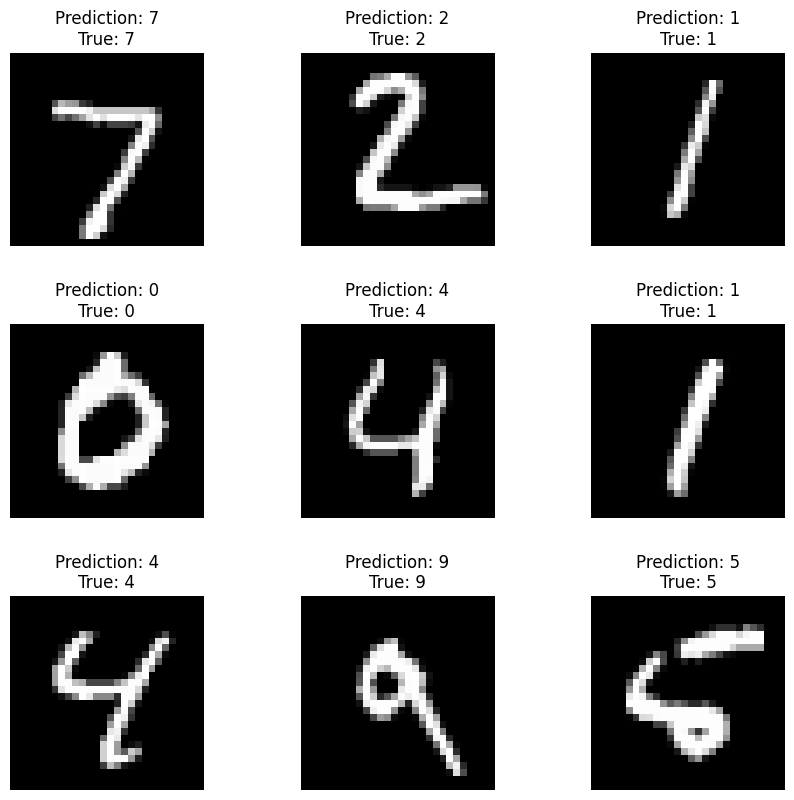

In [7]:
# Plot some sample images with predictions
def plot_sample_images(model, x_test, y_test):
    predictions = model.predict(x_test)
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    axes = axes.ravel()
    for i in np.arange(0, 9):
        axes[i].imshow(x_test[i].reshape(28, 28), cmap='gray')
        axes[i].set_title(f"Prediction: {np.argmax(predictions[i])}\nTrue: {y_test[i]}")
        axes[i].axis('off')
    plt.subplots_adjust(wspace=0.5)
    plt.show()

plot_sample_images(global_model, x_test, y_test)